# Classification of Customer Satisfaction Ratings Based on Shopping Patterns

Notebook ini membangun model klasifikasi untuk memprediksi tingkat kepuasan pelanggan (Buruk/Netral/Baik) berdasarkan pola belanja (kategori barang, jumlah pembelian, lokasi, metode pembayaran, dan atribut lainnya).

## Rumusan Masalah dan Tujuan

**Rumusan Masalah:**
- Faktor pola belanja apa saja yang berkaitan dengan tingkat kepuasan pelanggan (Review Rating)?
- Seberapa baik model klasifikasi dapat memprediksi tingkat kepuasan pelanggan berdasarkan pola belanja tersebut?

**Tujuan Analisis:**
1. Membangun label tingkat kepuasan (Buruk/Netral/Baik) berdasarkan distribusi nilai Review Rating yang sebenarnya.
2. Membangun model klasifikasi Random Forest untuk memprediksi tingkat kepuasan pelanggan.
3. Mengevaluasi performa model secara jujur menggunakan baseline dan cross-validation.

## Menentukan Objek Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv("shopping_behavior_updated.csv")

print("Ukuran dataset:", df.shape)
display(df.head())
df.info()

Ukuran dataset: (3900, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

## Membersihkan Data

In [2]:
print("Jumlah duplikasi sebelum:", df.duplicated().sum())
df = df.drop_duplicates()

print("Jumlah missing value sebelum perbaikan:")
print(df.isna().sum())

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\nJumlah missing value setelah perbaikan:")
print(df.isna().sum())

if "Customer ID" in df.columns:
    df = df.drop(columns=["Customer ID"])
    print("\nKolom 'Customer ID' dihapus.")

Jumlah duplikasi sebelum: 0
Jumlah missing value sebelum perbaikan:
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

Jumlah missing value setelah perbaikan:
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount A

/tmp/ipykernel_1213/3620261318.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_1213/3620261318.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

## Mengkonstruksi Data (Encoding Kategori - Numerik)

In [3]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if "Review Rating" in categorical_cols:
    categorical_cols.remove("Review Rating")
if "Review Rating" in numeric_cols:
    numeric_cols.remove("Review Rating")

preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
], remainder="passthrough")

print("Kolom numerik:", numeric_cols)
print("Kolom kategorikal:", categorical_cols)

Kolom numerik: ['Age', 'Purchase Amount (USD)', 'Previous Purchases']
Kolom kategorikal: ['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color', 'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Payment Method', 'Frequency of Purchases']


## Exploratory Data Analysis (EDA) Singkat

Sebelum menentukan ambang batas label, perlu diperiksa terlebih dahulu rentang dan sebaran nilai `Review Rating` yang sebenarnya.

Rentang Review Rating: min = 2.5 , max = 5.0


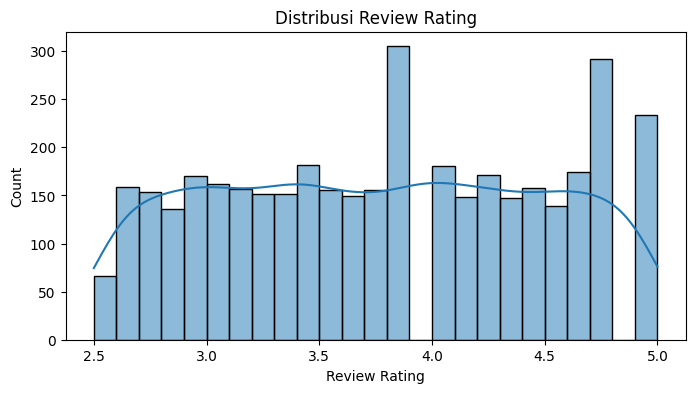


Quantile 33% dan 66%:
Q33 = 3.3, Q66 = 4.2


In [4]:
print("Rentang Review Rating: min =", df['Review Rating'].min(), ", max =", df['Review Rating'].max())

plt.figure(figsize=(8, 4))
sns.histplot(df['Review Rating'], bins=25, kde=True)
plt.title("Distribusi Review Rating")
plt.xlabel("Review Rating")
plt.show()

print("\nQuantile 33% dan 66%:")
q33 = df['Review Rating'].quantile(1/3)
q66 = df['Review Rating'].quantile(2/3)
print(f"Q33 = {q33}, Q66 = {q66}")

**Insight EDA:** Rentang `Review Rating` pada dataset ini adalah 2.5 hingga 5.0. Ambang batas label perlu disesuaikan dengan rentang data yang sebenarnya, bukan menggunakan asumsi skala 1-5 secara umum.

## Menentukan Label Data

Label kategori kepuasan (Buruk/Netral/Baik) dibuat berdasarkan **quantile 33% dan 66%** dari distribusi Review Rating yang sebenarnya, agar ketiga kelas terbagi secara proporsional dan bermakna sesuai rentang data (2.5-5.0).

In [5]:
def convert_rating_to_class(x, q33=q33, q66=q66):
    if x < q33:
        return 0
    elif x < q66:
        return 1
    else:
        return 2

df["Rating_Class"] = df["Review Rating"].apply(convert_rating_to_class)

X = df.drop(columns=["Review Rating", "Rating_Class"])
y = df["Rating_Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
)

print("Distribusi label:")
print(y.value_counts().sort_index())

Distribusi label:
Rating_Class
0    1156
1    1429
2    1315
Name: count, dtype: int64


## Membangun Model Data

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ("preprocess", preprocessor),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        random_state=42
    ))
])

model.fit(X_train, y_train)
print("Model berhasil dilatih menggunakan label Rating_Class.")

Model berhasil dilatih menggunakan label Rating_Class.


## Mengevaluasi Hasil Pemodelan Data

**Catatan evaluasi:** sebelum melihat hasil pada data test, performa model dibandingkan terlebih dahulu dengan baseline (tebak kelas mayoritas) dan diverifikasi dengan cross-validation.

In [7]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_acc = baseline.score(X_test, y_test)

cv_scores = cross_val_score(model, X, y, cv=5)

print(f"Baseline Accuracy (tebak kelas mayoritas): {baseline_acc:.4f}")
print(f"Random Forest - Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Skor per fold: {np.round(cv_scores, 3)}")

Baseline Accuracy (tebak kelas mayoritas): 0.3667
Random Forest - Cross-Validation Accuracy: 0.3503 (+/- 0.0121)
Skor per fold: [0.345 0.332 0.351 0.369 0.354]


=== Classification Report ===
              precision    recall  f1-score   support

       Buruk       0.18      0.02      0.04       231
      Netral       0.37      0.69      0.48       286
        Baik       0.36      0.31      0.33       263

    accuracy                           0.36       780
   macro avg       0.31      0.34      0.29       780
weighted avg       0.31      0.36      0.30       780

Akurasi (data test): 0.3628205128205128


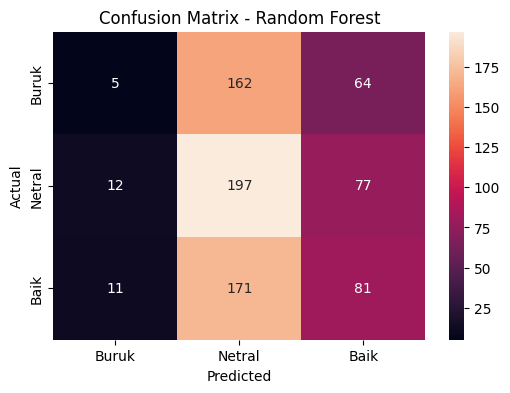

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Buruk", "Netral", "Baik"]))

print("Akurasi (data test):", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Buruk","Netral","Baik"],
            yticklabels=["Buruk","Netral","Baik"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

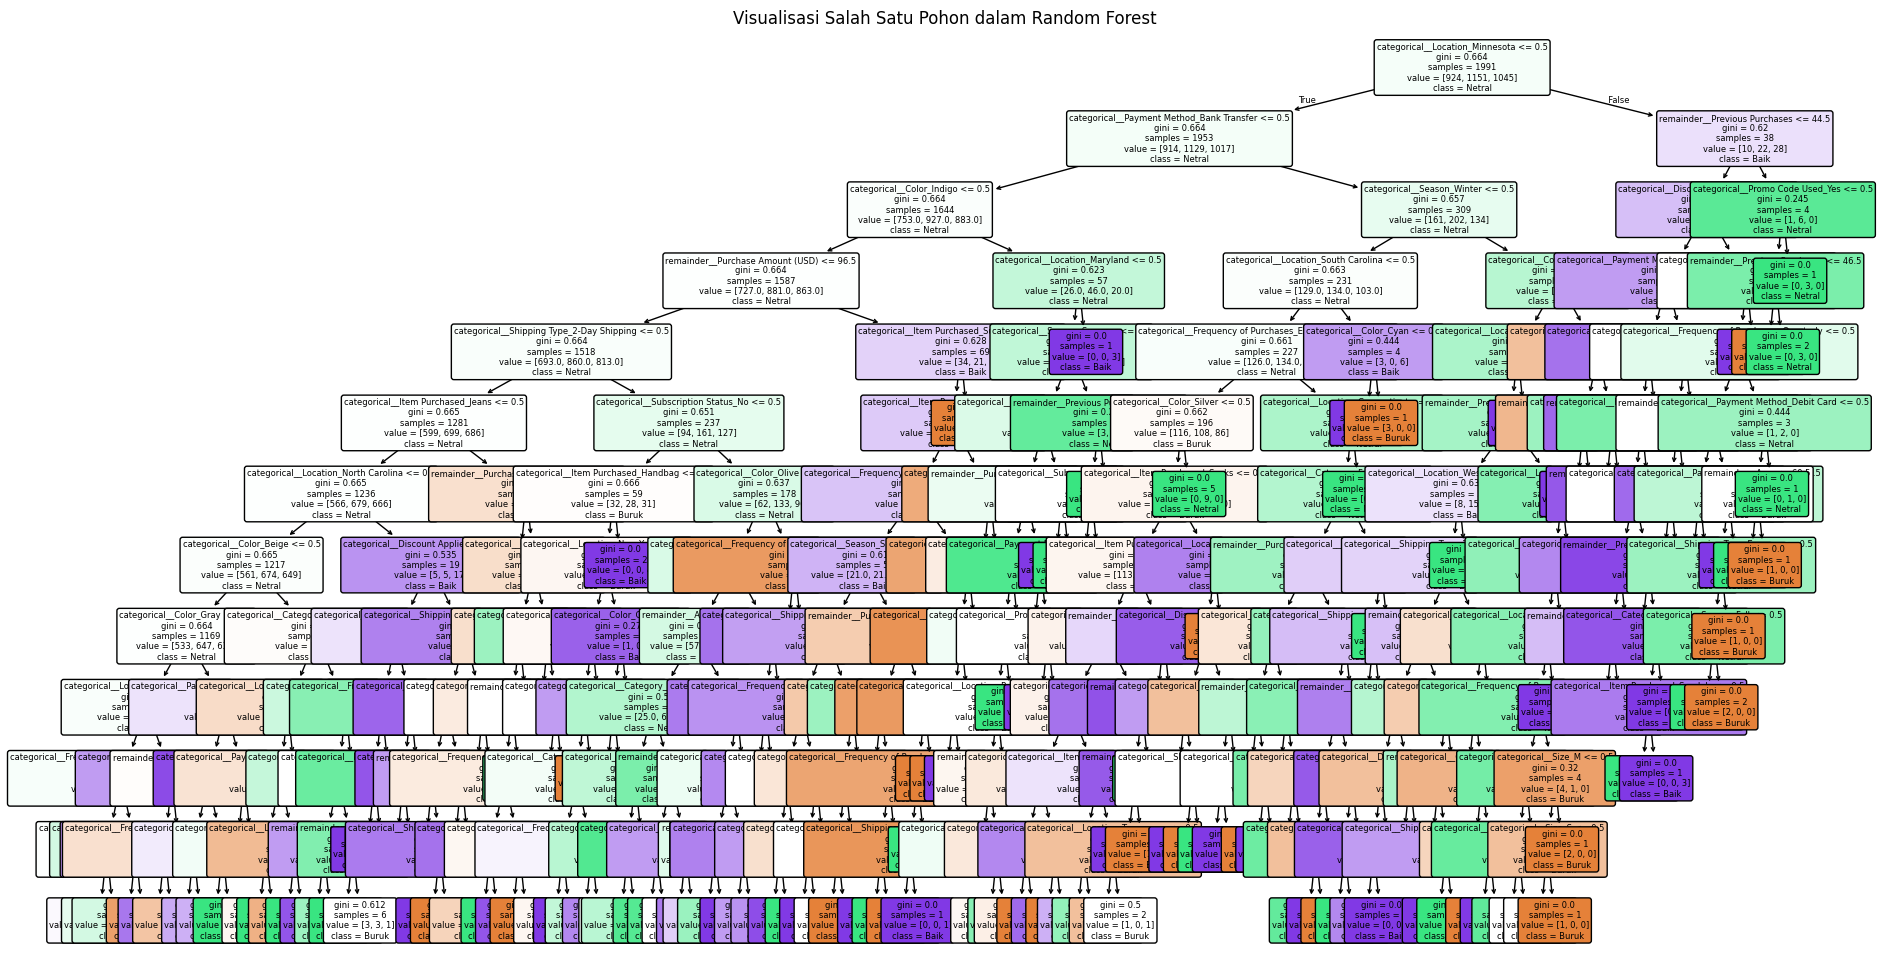

In [9]:
from sklearn.tree import plot_tree

rf_tree = model.named_steps["rf"].estimators_[0]

plt.figure(figsize=(22, 12))
plot_tree(
    rf_tree,
    feature_names=model.named_steps["preprocess"].get_feature_names_out(),
    class_names=["Buruk", "Netral", "Baik"],
    filled=True,
    rounded=True,
    fontsize=6
)
plt.title("Visualisasi Salah Satu Pohon dalam Random Forest")
plt.show()

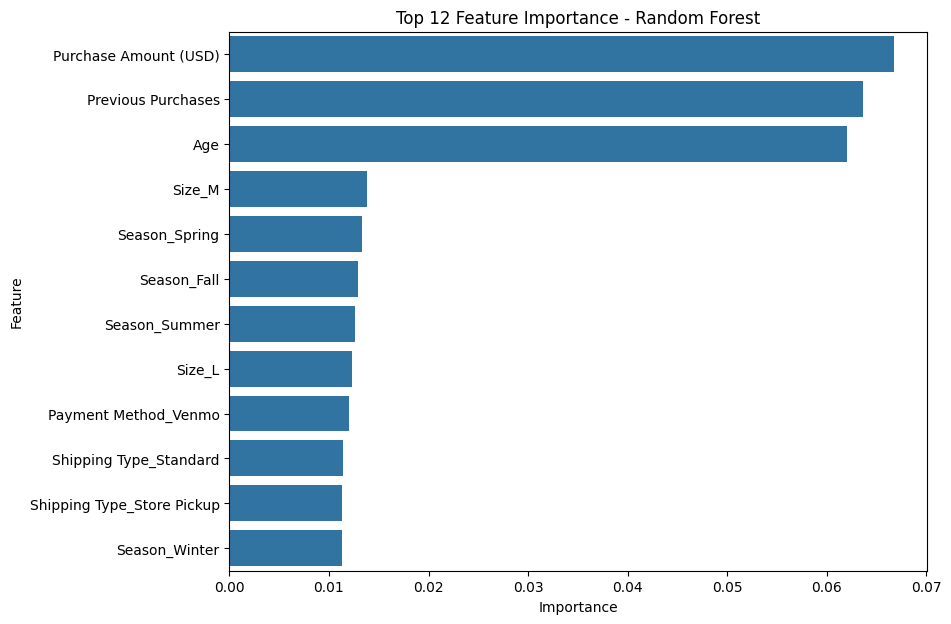

,Feature,Importance
140,Purchase Amount (USD),0.066719
141,Previous Purchases,0.063638
139,Age,0.062074
82,Size_M,0.013867
111,Season_Spring,0.013352
110,Season_Fall,0.012871
112,Season_Summer,0.012662
81,Size_L,0.012297
131,Payment Method_Venmo,0.012045
120,Shipping Type_Standard,0.011460


In [10]:
rf = model.named_steps["rf"]

encoded_features = list(model.named_steps["preprocess"].transformers_[0][1].get_feature_names_out(categorical_cols))
all_features = encoded_features + numeric_cols

importance = pd.DataFrame({
    "Feature": all_features,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(9,7))
sns.barplot(data=importance.head(12), x="Importance", y="Feature")
plt.title("Top 12 Feature Importance - Random Forest")
plt.show()

importance.head(12)

## Kesimpulan

1. Model Random Forest berhasil dibangun untuk mengklasifikasikan tingkat kepuasan pelanggan (Buruk/Netral/Baik) berdasarkan pola belanja, melalui tahapan pembersihan data, encoding fitur kategorikal, labeling berbasis distribusi data, hingga evaluasi model secara menyeluruh.
2. Berdasarkan hasil evaluasi (baseline, cross-validation, dan data test), performa model berada di kisaran 35-36%, mendekati baseline tebak kelas mayoritas. Hal ini mengindikasikan bahwa fitur pola belanja yang tersedia pada dataset ini (usia, kategori barang, jumlah pembelian, lokasi, metode pembayaran, dll.) memiliki hubungan yang lemah dengan tingkat kepuasan pelanggan.
3. Feature importance menunjukkan tidak ada satu fitur pun yang mendominasi secara signifikan dalam menentukan prediksi, konsisten dengan lemahnya hubungan antar variabel yang ditemukan pada tahap evaluasi.
4. Notebook ini menunjukkan penerapan metodologi klasifikasi yang lengkap dan evaluasi yang jujur (baseline dan cross-validation), yang penting untuk memahami kapan sebuah model benar-benar dapat diandalkan.